# --------- Assignment 01: Regression Models and EDA --------
# Name: Boualem Marir                                              
# Student Number: GEM/25/AIDS/1002
# School: Grenoble Ecole de Management – Alpine Business School
# Program: Master in Artificial Intelligence and Data Science

# Module: AIN7303 – Machine Learning and Deep Learning Techniques
# Faculty: Dr. David

# Assignment #1: CarDekho case study 
# ---------------------------------------------------------------------------

# ============================================================
# ASSIGNMENT 1 – Regression Models and EDA
# CarDekho Used Car Price Prediction using Linear Regression
# ============================================================

# ────────────────────────────────────────────────────────────
# Introduction
# ────────────────────────────────────────────────────────────

# This assignment applies the Week 1 machine learning workflow to the CarDekho dataset to predict used car selling prices using Linear Regression.

# I followed the full pipeline: preprocessing, feature engineering, feature selection, model training, evaluation, and residual analysis, independently using Python and Scikit-Learn as demonstrated in the live session.

# My focus was on understanding the reasoning behind each step rather than just running the code. Throughout the notebook I included observations and interpretations using machine learning terminology to critically reflect on the results and the limitations of the model.

In [7]:
# Section 0: Import Required Libraries 

import pandas as pd                                                              # data loading and manipulation
import numpy as np                                                               # numerical operations (e.g. np.sqrt for RMSE)
import matplotlib.pyplot as plt                                                  # data visualisation and plotting
import seaborn as sns                                                            # statistical visualisation (e.g. correlation heatmap)
from sklearn.model_selection import train_test_split                             # split data into training and testing sets
from sklearn.preprocessing import StandardScaler                                 # scale numerical features to mean=0, std=1
from sklearn.linear_model import LinearRegression                                # linear regression model for continuous target prediction
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score    # regression evaluation metrics: MAE, MSE, R²

print("All libraries imported successfully.")

All libraries imported successfully.


In [59]:
# Section 1: Data Loading & Exploration 

df = pd.read_csv("CAR DEKHO.csv", encoding="ISO-8859-1")  # encoding="ISO-8859-1" is used to handle special characters 
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [60]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4340, 8)


In [61]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [62]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB
None


# ============================================================
# TASK 1 – Data Preprocessing & Feature Engineering
# ============================================================

In [63]:
# Task 1a: Convert 'year' into 'car_age'

df['car_age'] = 2026 - df['year'] # car_age is calculated relative to 2026, the current year of analysis

df = df.drop(columns=['year'])    # Drop the original 'year' column as it is now replaced by car_age (redundancy)
df = df.drop(columns=['name'])    # Drop 'name' column. It contains string values which cannot be converted to float for correlation calculation

print(df[['car_age', 'selling_price']].head(5)) # Just to check the new variable "car age" was created correctly

   car_age  selling_price
0       19          60000
1       19         135000
2       14         600000
3        9         250000
4       12         450000


In [64]:
# Task 1b: Apply One-Hot Encoding to Categorical Features

# One-Hot Encoding converts categorical text columns into binary (0/1) numerical columns
# Categorical columns to encode:
   # fuel         → Petrol, Diesel, CNG, LPG, Electric
   # seller_type  → Dealer, Individual, Trustmark Dealer
   # transmission → Manual, Automatic
   # owner        → First Owner, Second Owner, Third Owner, Fourth & Above Owner, Test Drive Car

# drop_first=True drops one column per category to avoid the dummy variable trap
# (multicollinearity — when all dummy columns together perfectly predict each other)
df = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'owner'], drop_first=True)

# Verify encoding was applied — check new shape and column names
print("Dataset shape after One-Hot Encoding:", df.shape)
print("\nColumns after encoding:\n", df.columns.tolist())
df.head()

Dataset shape after One-Hot Encoding: (4340, 14)

Columns after encoding:
 ['selling_price', 'km_driven', 'car_age', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']


,selling_price,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,60000,70000,19,False,False,False,True,True,False,True,False,False,False,False
1,135000,50000,19,False,False,False,True,True,False,True,False,False,False,False
2,600000,100000,14,True,False,False,False,True,False,True,False,False,False,False
3,250000,46000,9,False,False,False,True,True,False,True,False,False,False,False
4,450000,141000,12,True,False,False,False,True,False,True,False,True,False,False


In [65]:
# Task 1c: Scale Numerical Features

# Feature scaling is applied because km_driven and car_age operate on very different scales
# km_driven ranges from ~1,000 to 500,000+ while car_age ranges from 1 to ~20
# Without scaling, the model assigns disproportionate weight to larger-valued features
# StandardScaler transforms each feature to have mean=0 and standard deviation=1
# This ensures all features contribute equally to the model's learning process

# ==> Note: Scaling will be applied after train-test split to prevent data leakage

# We will apply StandardScaler when we reach the train-test split task
# This placeholder confirms which numerical features will be scaled
numerical_features = ['km_driven', 'car_age']
print("Numerical features to be scaled:", numerical_features)

Numerical features to be scaled: ['km_driven', 'car_age']


# ============================================================
# TASK 2 – Feature Selection
# ============================================================

In [66]:
#  Task 2a: Compute Correlation Matrix & Identify Important Variables

# Compute correlation of all varaibles against the target variable (selling_price)
# Correlation measures the linear relationship strength between each feature and the target
# Values range from -1 (strong negative relationship) to +1 (strong positive relationship)
# Features with correlation close to 0 have little predictive value

corr = df.corr()['selling_price'].sort_values()
print("Correlation of all variables with selling_price:\n")  # prints each variable in a new line
print(corr)

Correlation of all features with selling_price:

transmission_Manual            -0.530205
car_age                        -0.413922
fuel_Petrol                    -0.269453
seller_type_Individual         -0.236798
km_driven                      -0.192289
owner_Second Owner             -0.161986
owner_Third Owner              -0.111326
owner_Fourth & Above Owner     -0.078725
fuel_LPG                       -0.042434
fuel_Electric                  -0.005095
owner_Test Drive Car            0.048799
seller_type_Trustmark Dealer    0.110176
fuel_Diesel                     0.282947
selling_price                   1.000000
Name: selling_price, dtype: float64


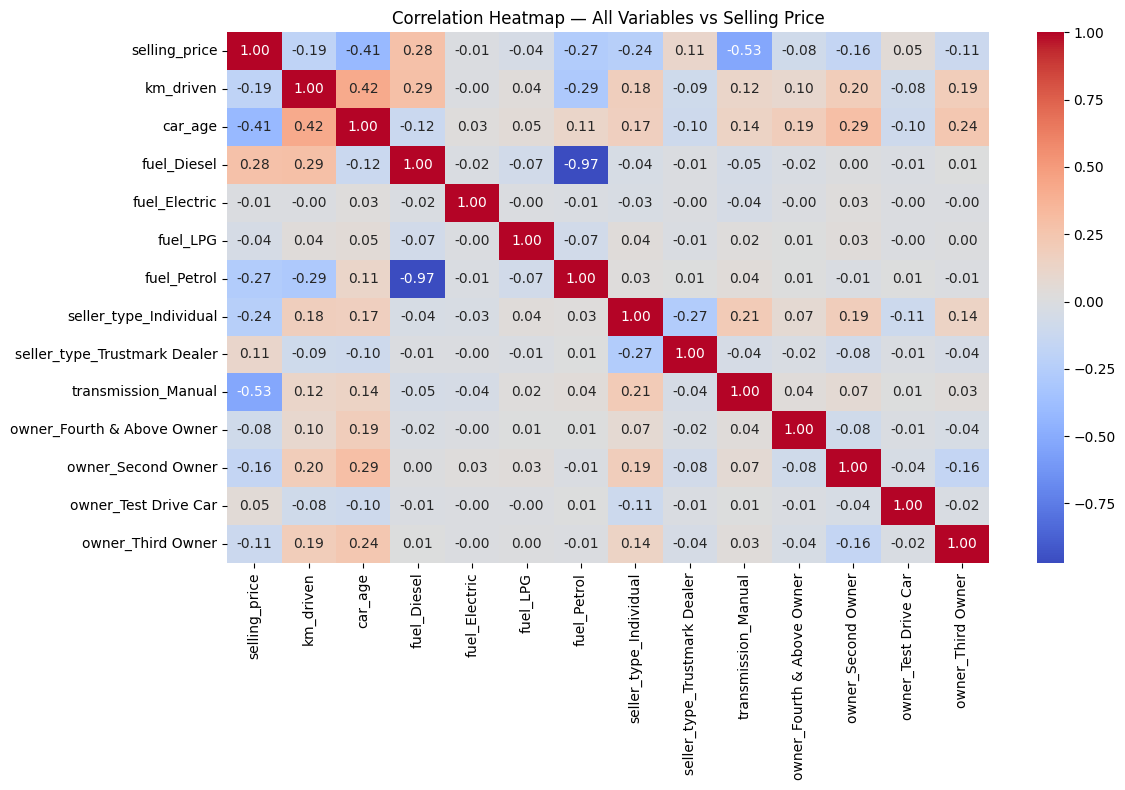

In [68]:
# Visualise the correlation matrix as a heatmap (as was done in Day 2 case)
# This helps identify both important variables and relationships between them

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')     # to add red/blue color scheme
plt.title("Correlation Heatmap — All Variables vs Selling Price")
plt.tight_layout()                                                 # to prevent labels cutoff
plt.show()

# Interpretation of Correlation Results:

# Manual transmission (-0.53) and car age (-0.41) show the strongest negative relationships ==> older manual cars tend to sell for much less

# Diesel fuel type (+0.28) is the only feature with a notable positive correlation ==> diesel cars generally fetch higher resale prices

# Higher km_driven (-0.19) unsurprisingly lowers the selling price ==> the more a car has been used, the less it is worth

# Fuel_Electric and fuel_LPG sit near zero: they have almost no linear relationship with price and will be excluded in the next step

In [69]:
# Task 2b: Select Relevant Features Based on Correlation > 0.1 or < -0.1

# Based on the correlation analysis (step above), features with |correlation| > 0.1
# with selling_price are selected as they show meaningful predictive value
# Features below this threshold are excluded as they add noise to the model

# Define input features (X) and target variable (y)
X = df[['transmission_Manual', 'car_age', 'fuel_Petrol',
        'seller_type_Individual', 'km_driven', 'owner_Second Owner',
        'owner_Third Owner', 'seller_type_Trustmark Dealer', 'fuel_Diesel']]

y = df['selling_price']

print("Selected features shape:", X.shape)   # confirms selected input features and dimensions
print("Target variable shape:", y.shape)     # confirms target variable was correctly assigned

Selected features shape: (4340, 9)
Target variable shape: (4340,)


# ============================================================
# TASK 3 – Train-Test Split & Model Training
# ============================================================

# Task 3a: Importance of Feature Scaling in This Dataset

# Feature scaling matters here because km_driven and car_age are on very different scales # km_driven can go up to 800,000+ while car_age only ranges from 1 to 20.

# If we don't scale, the model will be heavily influenced by km_driven not because it is more important but simply because its numbers are much larger.

# StandardScaler brings both features to the same scale (mean=0, std=1) so the model can fairly compare them during training.

In [70]:
# Task 3b: Train-Test Split

# Split the dataset into 75% training and 25% testing sets (similarly to what was done in class)
# Training set is used to learn patterns while testing set evaluates performance on unseen data
# random_state=42 ensures reproducibility — same split every time the code is run

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

print("Training set size:", X_train.shape)  # displays & confirms training data dimensions
print("Testing set size:", X_test.shape)    # displays & confirms testing data dimensions

Training set size: (3255, 9)
Testing set size: (1085, 9)


In [72]:
# Task 3c: Feature Scaling

# Numerical features to be scaled — carried forward from Task 1c above
# km_driven and car_age operate on very different scales
numerical_features = ['km_driven', 'car_age']

# fit_transform on training data ==> learns mean and std from training data only
# transform on test data only ==> applying same statistics prevents data leakage (as explained in the class material)

scaler = StandardScaler()
X_train[['km_driven', 'car_age']] = scaler.fit_transform(X_train[['km_driven', 'car_age']])  # fit and transform training data
X_test[['km_driven', 'car_age']]  = scaler.transform(X_test[['km_driven', 'car_age']])       # transform test data only

print("Numerical features scaled successfully.")
print(X_train[['km_driven', 'car_age']].head())  # verify scaling was applied

Numerical features scaled successfully.
      km_driven   car_age
2206   0.730339  1.453414
1159  -1.122892 -0.207953
2029  -0.594160 -0.682630
1779  -1.384374 -1.631982
3357  -0.536480  0.266723


# Output confirms scaling was applied successfully
# km_driven and car_age are now standardised to mean=0 and std=1
# Positive values indicate above average — negative values indicate below average
# Both features are now on the same scale for fair model comparison

# Note: 
# in practice it is common to scale all features including binary OHE columns
# however this assignment specifically requires scaling only the numerical features (km_driven and car_age) so I follow the assignment instructions accordingly.

In [73]:
# Task 3d: Train a Linear Regression model using Scikit-Learn

# Scikit-Learn is a Python machine learning library that provides
# ready to use implementations of ML algorithms including Linear Regression

# Linear Regression is suitable here because selling_price is a continuous numerical target variable
# not a category or class

# The model learns the relationship between input features and selling_price by
# finding the best fitting line that minimises prediction errors (MSE)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")
print("Intercept (b0):", model.intercept_)  # baseline selling_price when all features are zero
print("Coefficients:", model.coef_)         # impact of each feature on selling_price

Model trained successfully.
Intercept (b0): 1236233.526247675
Coefficients: [-886420.56133223 -151944.91096599  -23047.51516986  -68458.70743269
  -48184.77954529  -36909.81549324  -29516.19670772  159519.79942511
  277555.50604405]


# ============================================================
# TASK 4 – Model Evaluation
# ============================================================

In [74]:
# Task 4a: Evaluate the Model Using MAE, MSE, RMSE and R²

# First make predictions on the unseen test data
y_pred = model.predict(X_test)                # model predicts selling_price for test set

# Calculate evaluation metrics
mae  = mean_absolute_error(y_test, y_pred)   # average prediction error in original units
mse  = mean_squared_error(y_test, y_pred)    # penalises larger errors more heavily
rmse = np.sqrt(mse)                          # converts MSE back to original units (rupees)
r2   = r2_score(y_test, y_pred)              # proportion of variance explained by the model

print("Model Evaluation Metrics:")
print(f"MAE:  {mae:,.0f}")   # Mean Absolute Error
print(f"MSE:  {mse:,.0f}")   # Mean Squared Error
print(f"RMSE: {rmse:,.0f}")  # Root Mean Squared Error
print(f"R²:   {r2:.4f}")     # R-Squared Score

Model Evaluation Metrics:
MAE:  219,873
MSE:  173,709,303,916
RMSE: 416,784
R²:   0.4254


# Interpretation of Model Evaluation Metrics

# The evaluation metrics indicate that the Linear Regression model has moderate predictive performance for selling_price

# MAE (219,873): on average the predicted selling_price is off by 219,873, which is a notable error especially for cars priced under 500,000

# RMSE (416,784): the typical error in predicted selling_price is 416,784 higher than MAE because it penalises larger prediction mistakes more heavily

# R² (0.4254): the model explains only 42% of the variation in selling_price, meaning 58% of what drives the price is not captured by this model

# Overall the model gives a rough estimate of selling_price but lacks precision, suggesting that selling_price is influenced by non-linear factors that Linear Regression alone cannot fully capture.

# A more complex model such as Random Forest or Decision Tree would likely produce more accurate selling_price predictions.

In [75]:
# Task 4b: Compare Performance Before and After Feature Selection

# Model 1: Before Feature Selection — All Features

# Use all available features after One-Hot Encoding (13 features)
X_all = df.drop(columns=['selling_price'])
y     = df['selling_price']

# Train-Test Split
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y, test_size=0.25, random_state=42)

# Scale numerical features
scaler_all = StandardScaler()
X_train_all[['km_driven', 'car_age']] = scaler_all.fit_transform(
    X_train_all[['km_driven', 'car_age']])
X_test_all[['km_driven', 'car_age']]  = scaler_all.transform(
    X_test_all[['km_driven', 'car_age']])

# Train and evaluate
model_all  = LinearRegression()
model_all.fit(X_train_all, y_train_all)
y_pred_all = model_all.predict(X_test_all)

mae_all  = mean_absolute_error(y_test_all, y_pred_all)
mse_all  = mean_squared_error(y_test_all, y_pred_all)
rmse_all = np.sqrt(mse_all)
r2_all   = r2_score(y_test_all, y_pred_all)

In [76]:
# Model 2: After Feature Selection — Selected Features Only

# Use only features with |correlation| > 0.1 with selling_price (9 features)
X_sel = df[['transmission_Manual', 'car_age', 'fuel_Petrol',
            'seller_type_Individual', 'km_driven', 'owner_Second Owner',
            'owner_Third Owner', 'seller_type_Trustmark Dealer', 'fuel_Diesel']]

# Train-Test Split
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_sel, y, test_size=0.25, random_state=42)

# Scale numerical features
scaler_sel = StandardScaler()
X_train_sel[['km_driven', 'car_age']] = scaler_sel.fit_transform(
    X_train_sel[['km_driven', 'car_age']])
X_test_sel[['km_driven', 'car_age']]  = scaler_sel.transform(
    X_test_sel[['km_driven', 'car_age']])

# Train and evaluate
model_sel  = LinearRegression()
model_sel.fit(X_train_sel, y_train_sel)
y_pred_sel = model_sel.predict(X_test_sel)

mae_sel  = mean_absolute_error(y_test_sel, y_pred_sel)
mse_sel  = mean_squared_error(y_test_sel, y_pred_sel)
rmse_sel = np.sqrt(mse_sel)
r2_sel   = r2_score(y_test_sel, y_pred_sel)

In [77]:
# Comparison Table
print("=" * 55)
print(f"{'Metric':<10} {'All Features':>20} {'Selected Features':>20}")
print("=" * 55)
print(f"{'MAE':<10} {mae_all:>20,.0f} {mae_sel:>20,.0f}")
print(f"{'MSE':<10} {mse_all:>20,.0f} {mse_sel:>20,.0f}")
print(f"{'RMSE':<10} {rmse_all:>20,.0f} {rmse_sel:>20,.0f}")
print(f"{'R²':<10} {r2_all:>20.4f} {r2_sel:>20.4f}")
print("=" * 55)

Metric             All Features    Selected Features
MAE                     219,771              219,873
MSE             173,645,859,246      173,709,303,916
RMSE                    416,708              416,784
R²                       0.4256               0.4254


# Comparison: Interpretation of Before vs After Feature Selection

# The results are almost identical between both models

# R² dropped only marginally from 0.4256 to 0.4254 after removing 4 features

# RMSE increased very slightly from 416,708 to 416,784; a negligible difference

# This confirms that the 4 dropped features (fuel_Electric, fuel_LPG, owner_Fourth & Above Owner, owner_Test Drive Car) had almost no impact on predicting selling_price ==> consistent with their near-zero correlation

# The simpler model with 9 features performs just as well as the full model with 13 features, making it the preferred choice for interpretability.

# ============================================================
# TASK 5 – Residual Analysis & Performance Visualization
# ============================================================

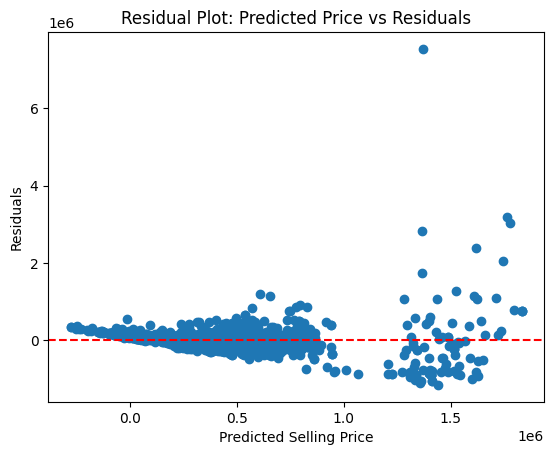

In [80]:
# Task 5a: Plot Residual Errors and Explain Their Distribution

# Residuals are the differences between actual and predicted selling_price
# Residual = Actual selling_price - Predicted selling_price
# A good model should have residuals randomly scattered around zero
# Patterns in residuals indicate the model is missing important information

residuals = y_test_sel - y_pred_sel  # calculate residuals

# Residual Plot

# Plots predicted selling_price on x-axis and residuals on y-axis

plt.scatter(y_pred_sel, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residuals")
plt.title("Residual Plot: Predicted Price vs Residuals")
plt.show()

# Interpretation:

# The residuals for most cars are randomly scattered around zero, which is a good sign — the model is performing reasonably well on the majority of the data.

# However, at higher predicted prices, the errors spread out significantly, suggesting the model struggles with expensive cars. This is likely due to non-linear relationships in premium car pricing that Linear Regression cannot fully capture.

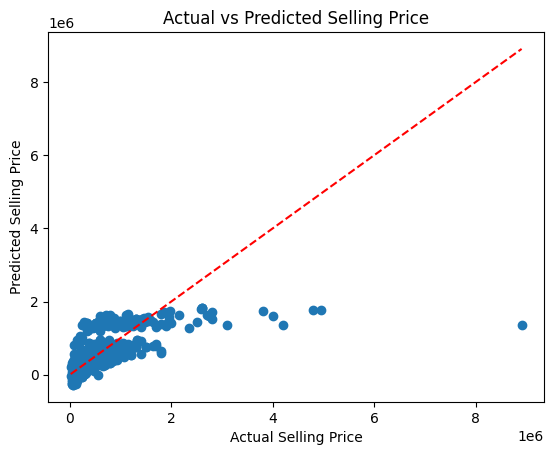

In [81]:
# Task 5b: Actual vs Predicted Price Scatter Plot

# Plots actual selling_price on x-axis and predicted selling_price on y-axis
# If predictions were perfect all points would lie exactly on the red diagonal line
# Points close to the line indicate accurate predictions
# Points far from the line indicate large prediction errors

plt.scatter(y_test_sel, y_pred_sel)
plt.plot([y_test_sel.min(), y_test_sel.max()],
         [y_test_sel.min(), y_test_sel.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()

# Interpretation:

# Most points are clustered near the bottom-left — the model does reasonably well for cheap, everyday cars.
# But as actual price increases, points drift far below the red line, meaning the model consistently underpredicts expensive cars. It just can't keep up with premium pricing.

# Bottom line: the model is decent for budget cars but loses accuracy fast once prices go up ==> classic sign of non-linearity that Linear Regression can't handle.

# Task 5c: Is Linear Regression the Best Model for Car Price Prediction?

# Based on the results of this analysis, Linear Regression is not the best model for predicting car selling_price; here is why:

# The residual plot and the actual vs predicted plot both tell the same story: the model handles cheap, common cars reasonably well but completely falls apart for high-priced cars.

# Linear Regression assumes a straight-line relationship between features and price, but car pricing doesn't work that way. A luxury car isn't just "more km driven = lower price." There are complex interactions between fuel type, transmission, ownership history and year that a straight line simply can't capture.

# R² of 0.4254 means the model only explains 42% of the variation in selling_price, a strong model would typically achieve R² above 0.7.

# Car pricing is influenced by complex non-linear interactions between features like brand reputation, condition, and market demand which Linear Regression cannot capture with a straight line equation.

# A Decision Tree or Random Forest Regressor would be a much better fit (as studied in this module) since they handle non-linear relationships and feature interactions naturally, without assuming anything about the shape of the data.

# ──────────────────────────────────────────────────────────────────────────────
# Conclusion, Learning & Reflection
# ──────────────────────────────────────────────────────────────────────────────

# This assignment helped me understand how machine learning is applied in a real business context. Working through the CarDekho case from raw data, data processing, and to model evaluation made the Week 1 concepts feel much more tangible and practical.

# The biggest takeaway for me was how much work goes into preparing the data before training a model. Creating car_age, encoding categorical variables, and scaling numerical features were steps I initially underestimated, but each one had a direct impact on how well the model could learn.

# The results were eye opening. An R² of 0.4254 tells me that Linear Regression only explains 42% of what drives selling_price, which is honestly not great. The residual plots made it clear that car pricing is more complex than a  straight line equation can handle. This made me realise that picking the right model matters just as much as implementing it correctly.

# Overall this assignment taught me that machine learning is not just about writing code, it is about understanding the data, making justified decisions, and being honest about the limitations of your results.